In [18]:
from datetime import datetime, timedelta
from astropy.time import Time
import matplotlib.pyplot as plt

import gpstime
import glob
import os
import uproot
import pandas as pd

# Observe the GWOSC intervals for O3

In [5]:
basedata = os.getcwd()
basedata

'C:\\Users\\erick\\Downloads\\JupyterNotebook\\github\\tSNE_analysis\\Virgo'

In [19]:
intervals = pd.read_csv(basedata + '/zrepository/gwoscO3atxt.txt', sep=' ', header=None, names=['int1', 'int2', 'duration'])
intervals

,int1,int2,duration
0,1238166018,1238186420,20402
1,1238186428,1238220967,34539
2,1238250278,1238252421,2143
3,1238252597,1238257817,5220
4,1238257971,1238261506,3535
...,...,...,...
1345,1253830620,1253863588,32968
1346,1253866050,1253872893,6843
1347,1253909276,1253915996,6720
1348,1253916002,1253941833,25831


In [38]:
date_start = "2019-09-22 01:00"
date_end = "2019-10-01 15:00"

start = Time(date_start, scale="utc").gps
end = Time(date_end, scale="utc").gps

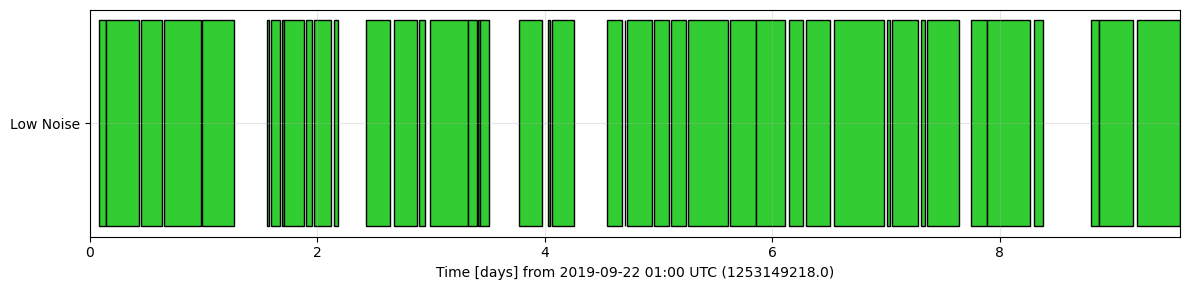

In [39]:
df = intervals[(intervals['int1'] >= start) & (intervals['int2'] <= end)]

inicio_dias = (df['int1'] - start) / 86400
duracao_dias = df['duration'] / 86400

plt.figure(figsize=(12, 3))
plt.barh(y=0, width=duracao_dias, left=inicio_dias, height=0.5, color='limegreen', edgecolor='black')

plt.yticks([0], ['Low Noise'])
plt.xlabel(f'Time [days] from {date_start} UTC ({start})')
plt.xlim(0, (end - start) / 86400)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Clustering from Detchar Group

In [2]:
def find_trigger_files(ch, start, end, trigpath="/data/*/omicron/", ext="root"):
    
    allfiles = glob.glob(os.path.join(trigpath, "{}/{}_OMICRON".format(*ch.split(":")), "**", f"*.{ext}"), recursive=True)
    if not allfiles:
        print(f"Nenhum arquivo encontrado no caminho {trigpath}")
        return []
    allstart, alldur = np.array([f.rstrip(f".{ext}").split("-")[-2:] for f in allfiles]).astype(int).T
    try:
        rightfiles = np.asarray(allfiles)[(allstart + alldur > start) & (end > allstart)]
    except TypeError:
        print(f"Nenhum arquivo relevante encontrado entre {start} e {end}")
        return []
    return rightfiles

In [3]:
def clusterize_triggers(table, window=0.1):
    if len(table) == 0:
        return EventTable(rows=[])  # retorna tabela vazia se não houver triggers

    table = table.copy()
    table.sort('tstart')

    cluster_ids = np.zeros(len(table), dtype=int)
    cluster_index = 0
    for i in range(1, len(table)):
        delta_t = table[i]['tstart'] - table[i-1]['tend']
        if delta_t <= window:
            cluster_ids[i] = cluster_index
        else:
            cluster_index += 1
            cluster_ids[i] = cluster_index

    table['cluster'] = cluster_ids
    summary_rows = []
    for cl in np.unique(cluster_ids):
        cluster_rows = table[table['cluster'] == cl]
        if len(cluster_rows) == 0:
            continue
        max_idx = np.argmax(cluster_rows['snr'])
        max_row = cluster_rows[max_idx]

        summary_rows.append({
            'cluster': cl,
            'tstart': np.min(cluster_rows['tstart']),
            'tend': np.max(cluster_rows['tend']),
            'fmin': np.min(cluster_rows['fstart']),
            'fmax': np.max(cluster_rows['fend']),
            'time': max_row['time'],
            'frequency': max_row['frequency'],
            'q': max_row['q'],
            'snr': max_row['snr'],
            'phase': max_row['phase']
        })
    return EventTable(rows=summary_rows)

In [4]:
ch = "V1:Hrec_hoft_16384Hz"
chDQ = "V1:META_ITF_LOCK_index"
state_val = 135  # low-noise

#Janela de operação
run_start_day = datetime(2024, 5, 10, 0, 0, 0)
run_end_day   = datetime(2024, 5, 20, 23, 59, 59)


snr_thresholds = [6.5, 10] #SNR_cut
cluster_window = 0.1  # Janela de clusterização (segundos)

days_per_part = 20
part_number = 1
current_day = run_start_day
monthly_results = []

In [11]:
# ---------------- Loop principal ----------------
while current_day <= run_end_day:
    day_start = datetime(current_day.year, current_day.month, current_day.day, 0, 0, 0)
    day_end   = datetime(current_day.year, current_day.month, current_day.day, 23, 59, 59)
    print(f"Processando dia: {current_day.date()}")

    # --- tempo ativo ---
    try:
        total_active_seconds, DQ = dq_active_seconds(chDQ, state_val, day_start, day_end)
    except Exception as e:
        print(f"  Falha ao obter DQ ({current_day.date()}): {e}")
        total_active_seconds = 0.0
    total_active_hours = total_active_seconds / 3600.0

    # --- triggers ---
    gps_start = Time(day_start, scale="utc").gps
    gps_end = Time(day_end, scale="utc").gps
    trigfiles = find_trigger_files(ch, gps_start, gps_end)
    
    if len(trigfiles) == 0:
        print(f"Nenhum arquivo encontrado para o dia {day_start.date()}")
        gltab = pd.DataFrame()
    else:
        # 1. Abre o arquivo ROOT e carrega a árvore 'triggers' para um DataFrame
        with uproot.open(trigfiles[0]) as file:
            gltab = file["triggers"].arrays(library="pd")
    
        # 2. Ordena por tempo (se a tabela não estiver vazia)
        if not gltab.empty:
            gltab = gltab.sort_values(by="time").reset_index(drop=True)
    
            # 3. Substituição do at_unique: remove gatilhos duplicados baseados no tempo
            gltab = gltab.drop_duplicates(subset=["time"]).reset_index(drop=True)

print(f"{gltab}\n\n")

# --- clusterização ---
if not gltab.empty:
    clustered = clusterize_triggers(gltab, window=cluster_window)
else:
    clustered = pd.DataFrame()

    # --- counts pós SNR cut ---
    counts_nonclustered = {snr: int(np.sum(gltab['snr'] > snr)) if len(gltab) > 0 else 0 for snr in snr_thresholds}
    counts_clustered   = {snr: int(np.sum(clustered['snr'] > snr)) if len(clustered) > 0 else 0 for snr in snr_thresholds}

    monthly_results.append({
        "date": current_day.date(),
        "n_triggers_nonclustered": int(len(gltab)),
        "n_triggers_clustered": int(len(clustered)),
        "counts_nonclustered": counts_nonclustered,
        "counts_clustered": counts_clustered,
        "total_active_seconds": total_active_seconds
    })

    # --- salvar parcial ---
    if len(monthly_results) % days_per_part == 0:
        fname = f"O4b_part{part_number}.npy"
        np.save(fname, monthly_results)
        print(f"=== Resultados parciais salvos em {fname} ===\n")
        part_number += 1
        monthly_results = []

    current_day += timedelta(days=1)

Processando dia: 2024-05-10
  Falha ao obter DQ (2024-05-10): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-10
Processando dia: 2024-05-10
  Falha ao obter DQ (2024-05-10): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-10
Processando dia: 2024-05-10
  Falha ao obter DQ (2024-05-10): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-10
Processando dia: 2024-05-10
  Falha ao obter DQ (2024-05-10): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-10
Processando dia: 2024-05-10
  Falha ao obter DQ (2024-05-10): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado pa

KeyboardInterrupt: 

In [ ]:
# --- salvar última parte ---
if len(monthly_results) > 0:
    fname = f"O4b_part{part_number}.npy"
    np.save(fname, monthly_results)
    print(f"=== Última parte salva em {fname} ===\n")

# ---------------- Combinar todas as partes em CSV final ----------------
all_parts = []
part_number = 1
while True:
    fname = f"O4b_part{part_number}.npy"
    if not os.path.exists(fname):
        break
    arr = np.load(fname, allow_pickle=True)
    all_parts.extend(arr)
    part_number += 1

# converter para DataFrame
df = pd.DataFrame(all_parts)

# remover linhas com counts zero
def nonzero_counts(row):
    nc = row.get('counts_nonclustered', {}) if isinstance(row.get('counts_nonclustered', {}), dict) else {}
    c  = row.get('counts_clustered', {}) if isinstance(row.get('counts_clustered', {}), dict) else {}
    return any(v > 0 for v in nc.values()) or any(v > 0 for v in c.values())

df = df[df.apply(nonzero_counts, axis=1)]

# salvar CSV final
df.to_csv("O4b_full.csv", index=False)
print("Arquivo final salvo: O4b_full.csv")